In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns
sns.get_dataset_names()


['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [8]:
tips= sns.load_dataset('tips')

In [9]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
tips.shape[0]

244

In [11]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [12]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [13]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [14]:
avg_tips_day_time= tips.groupby(['day', 'time'])['tip'].mean().round(2)
print ("Average tip by day and time:  ")
print (avg_tips_day_time)

Average tip by day and time:  
day   time  
Thur  Lunch     2.77
      Dinner    3.00
Fri   Lunch     2.38
      Dinner    2.94
Sat   Lunch      NaN
      Dinner    2.99
Sun   Lunch      NaN
      Dinner    3.26
Name: tip, dtype: float64


/tmp/ipykernel_169/2323466055.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tips_day_time= tips.groupby(['day', 'time'])['tip'].mean().round(2)


In [15]:
avg_tips_day_time= tips.groupby(['day', 'time'], observed= False)['tip'].mean().round(2).fillna('No Data')
print ("Average tip by day and time:  ")
print (avg_tips_day_time)

Average tip by day and time:  
day   time  
Thur  Lunch        2.77
      Dinner        3.0
Fri   Lunch        2.38
      Dinner       2.94
Sat   Lunch     No Data
      Dinner       2.99
Sun   Lunch     No Data
      Dinner       3.26
Name: tip, dtype: object


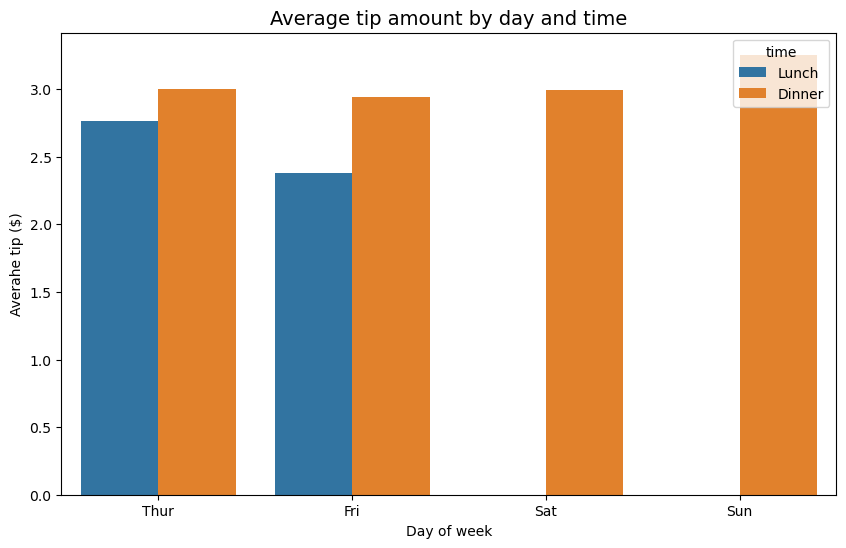

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x='day', y='tip', hue='time', data=tips, errorbar= None)
plt.title('Average tip amount by day and time', fontsize=14)
plt.xlabel('Day of week')
plt.ylabel('Averahe tip ($)')
plt.show()

In [17]:
avg_tip_by_gender= tips.groupby('sex')['tip'].mean().round(2)
print ("Average tip by Gender : " )
print (avg_tip_by_gender)

Average tip by Gender : 
sex
Male      3.09
Female    2.83
Name: tip, dtype: float64


/tmp/ipykernel_169/754934533.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_gender= tips.groupby('sex')['tip'].mean().round(2)


/tmp/ipykernel_169/2451657029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='tip', data=tips, palette= 'Set2')


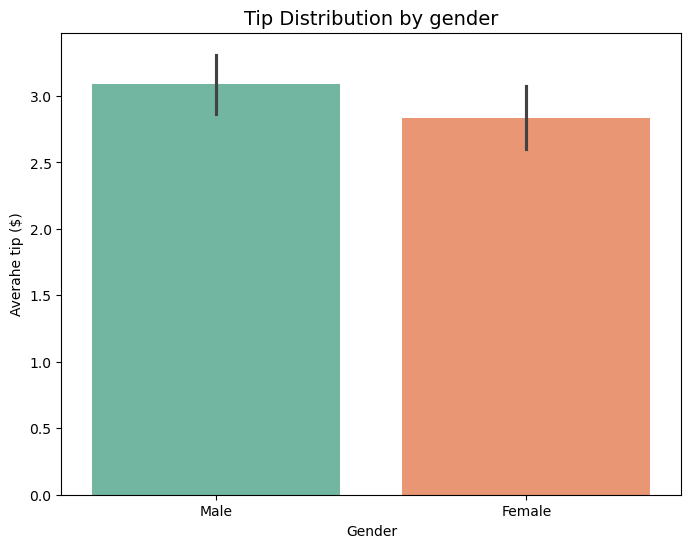

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(x='sex', y='tip', data=tips, palette= 'Set2')
plt.title('Tip Distribution by gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Averahe tip ($)')
plt.show()

In [19]:
correlation= tips['total_bill']. corr(tips['tip'])
print (f"Correlation between total_bill and tip: {correlation:.3f}")

Correlation between total_bill and tip: 0.676


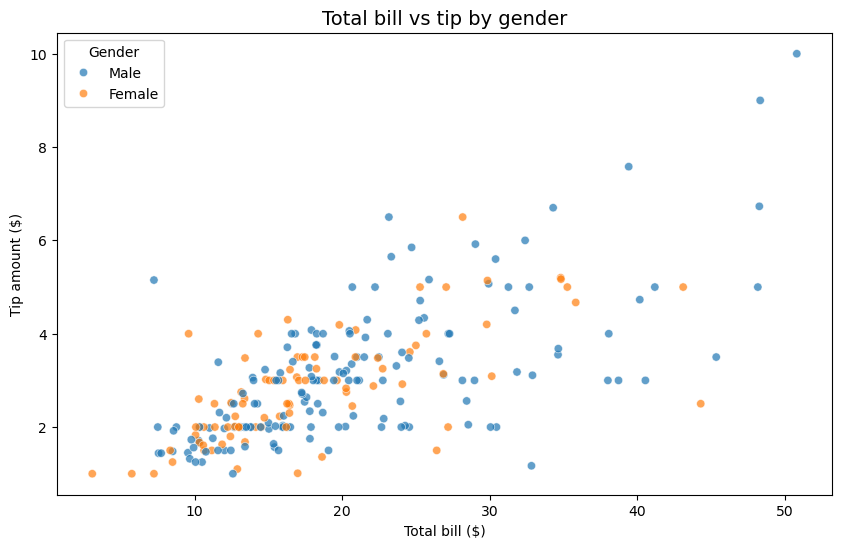

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='total_bill', y='tip', hue='sex', data=tips, alpha= 0.7)
plt.title('Total bill vs tip by gender', fontsize=14)
plt.xlabel('Total bill ($)')
plt.ylabel('Tip amount ($)')
plt.legend(title='Gender')
plt.show()

In [21]:
tips['tip_percentage']=(tips['tip']/ tips['total_bill'])*100
avg_tip_pct_by_size= tips.groupby('size')['tip_percentage'].mean().round(2)
print( "Average tip percentage by size:")
print (avg_tip_pct_by_size)

Average tip percentage by size:
size
1    21.73
2    16.57
3    15.22
4    14.59
5    14.15
6    15.62
Name: tip_percentage, dtype: float64


/tmp/ipykernel_169/2118477199.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='size', y='tip_percentage', data=tips, ci= None, palette= 'Blues_d')
/tmp/ipykernel_169/2118477199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='size', y='tip_percentage', data=tips, ci= None, palette= 'Blues_d')


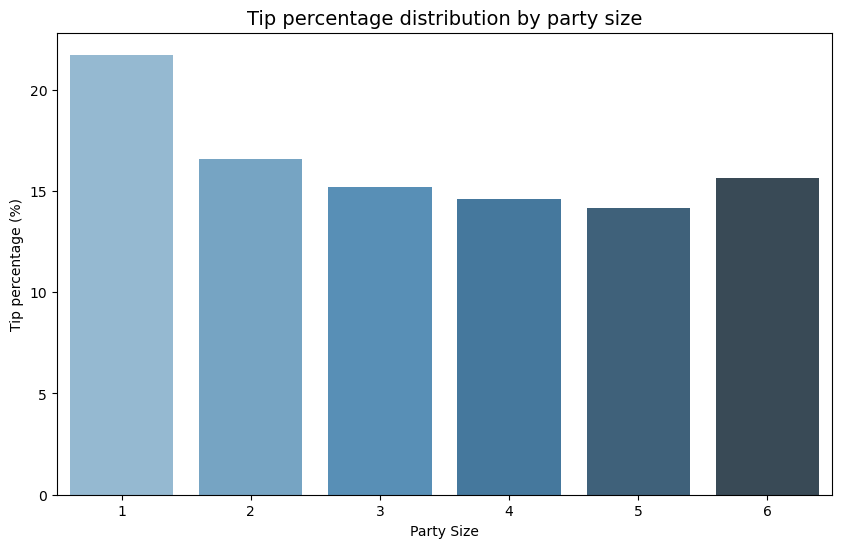

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x='size', y='tip_percentage', data=tips, ci= None, palette= 'Blues_d')
plt.title('Tip percentage distribution by party size', fontsize=14)
plt.xlabel('Party Size')
plt.ylabel('Tip percentage (%)')
plt.show()

In [23]:
avg_bill_day= tips.groupby('day')['total_bill'].mean().round(2).sort_values(ascending = False)
print("Average total bill by day: ")
print(avg_bill_day)

Average total bill by day: 
day
Sun     21.41
Sat     20.44
Thur    17.68
Fri     17.15
Name: total_bill, dtype: float64


/tmp/ipykernel_169/1607876618.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill_day= tips.groupby('day')['total_bill'].mean().round(2).sort_values(ascending = False)


/tmp/ipykernel_169/1078265646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day', y='total_bill', data=tips,palette='viridis', errorbar=None)


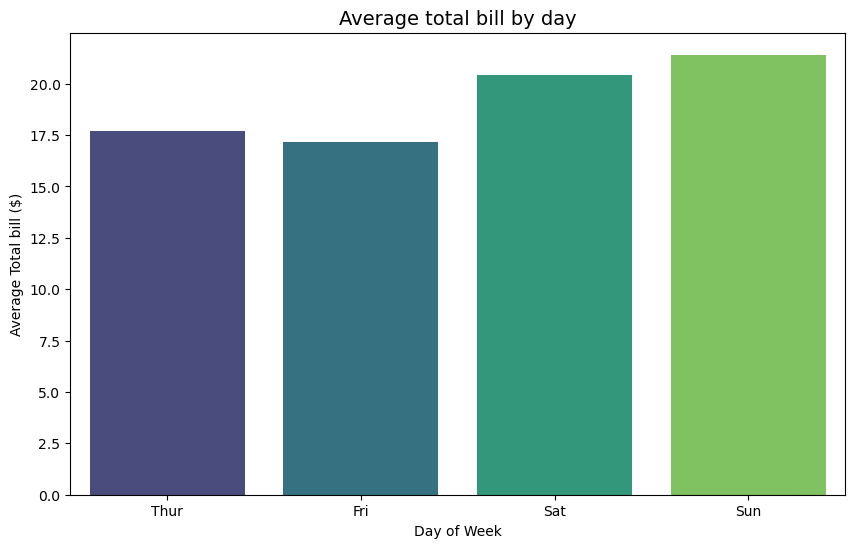

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x='day', y='total_bill', data=tips,palette='viridis', errorbar=None)
plt.title('Average total bill by day', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Total bill ($)')
plt.show()

In [25]:
avg_tip_smoker= tips.groupby('smoker')['tip'].mean(). round(2)
print("Average tip by smoker status: ")
print (avg_tip_smoker)

Average tip by smoker status: 
smoker
Yes    3.01
No     2.99
Name: tip, dtype: float64


/tmp/ipykernel_169/3212186562.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_smoker= tips.groupby('smoker')['tip'].mean(). round(2)


/tmp/ipykernel_169/1112702989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='tip', data=tips, palette='Set1')
/tmp/ipykernel_169/1112702989.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Gender')


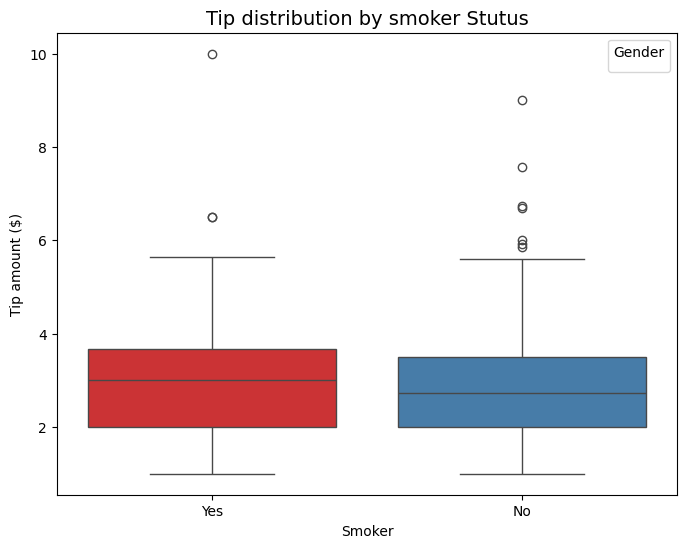

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='tip', data=tips, palette='Set1')
plt.title('Tip distribution by smoker Stutus', fontsize=14)
plt.xlabel('Smoker')
plt.ylabel('Tip amount ($)')
plt.legend(title='Gender')
plt.show()

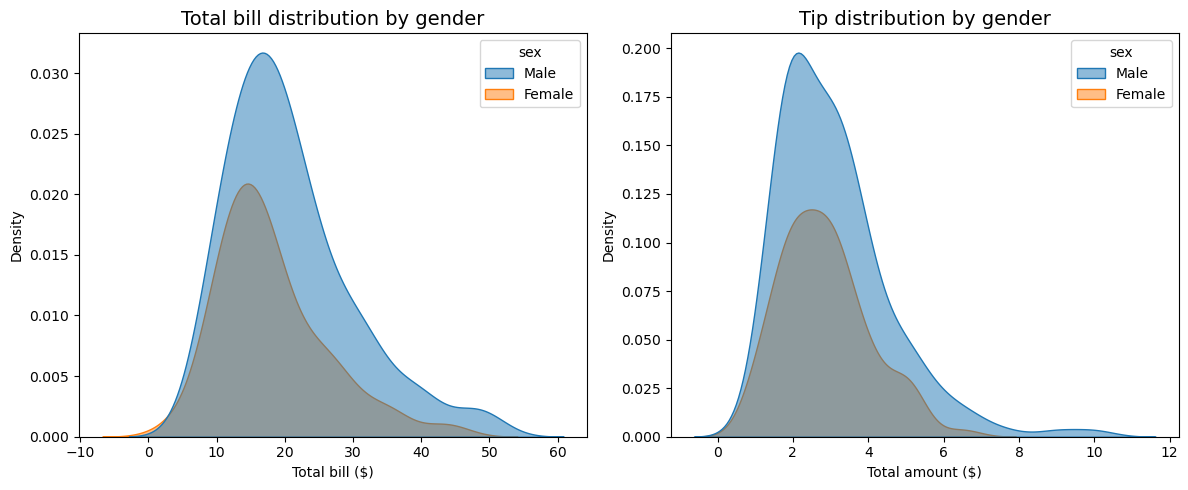

In [27]:
plt.figure(figsize= (12,5))
plt.subplot(1,2,1)
sns.kdeplot(data=tips, x='total_bill', hue='sex', fill= True, alpha= 0.5)
plt.title('Total bill distribution by gender', fontsize=14)
plt.xlabel('Total bill ($)')
plt.subplot(1,2,2)
sns.kdeplot(data=tips, x='tip', hue='sex', fill= True, alpha= 0.5)
plt.title('Tip distribution by gender', fontsize=14)
plt.xlabel('Total amount ($)')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

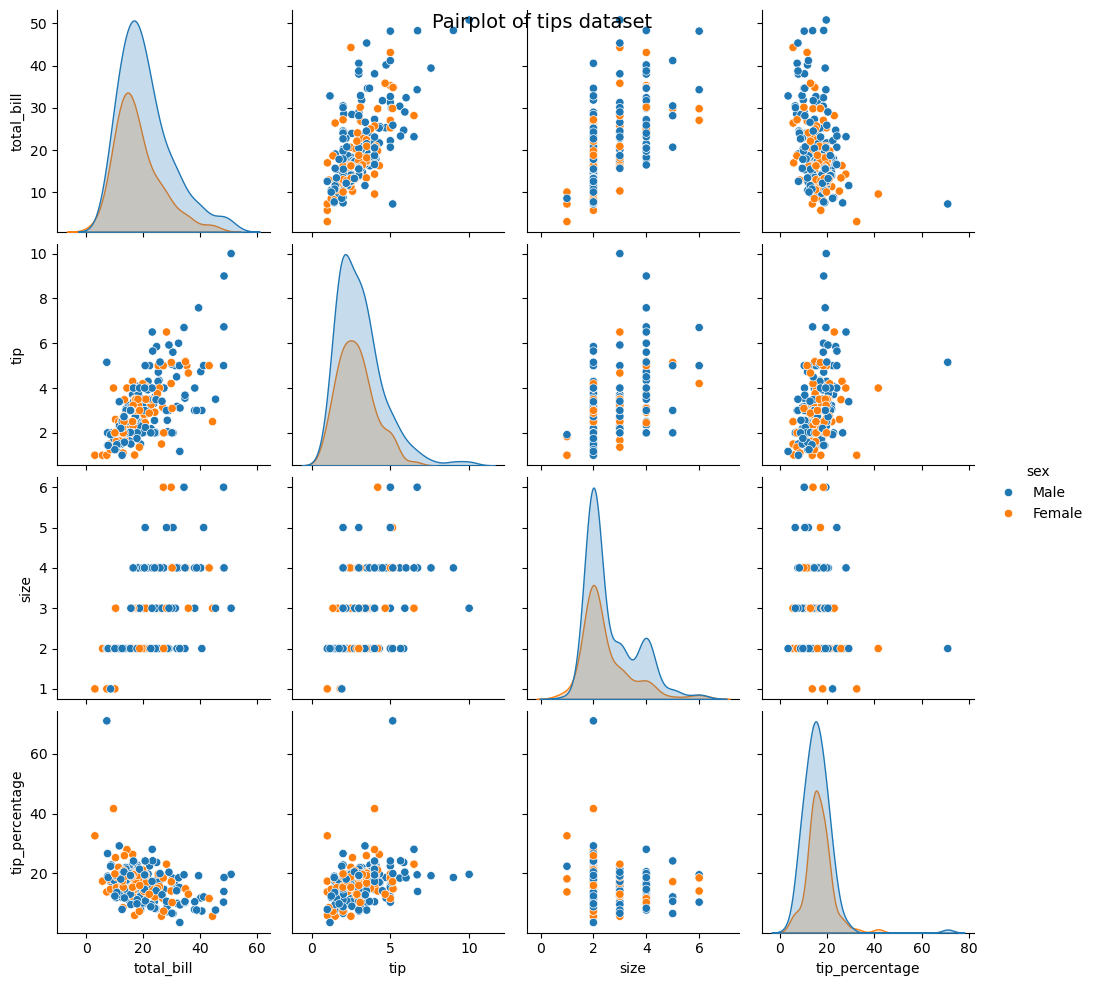

In [28]:
plt.figure(figsize=(10,8))
sns.pairplot(tips, hue='sex', diag_kind='kde')
plt.suptitle('Pairplot of tips dataset', fontsize=14)
plt.show()

In [30]:
print ("="*50)
print("Key Findings- Tips Dataset")
print ("="*50)
print ("\n1. Average tip by day and Time:")
print (tips.groupby(['day', 'time'])['tip'].mean().round(2))
print ("\n2. Average tips by Gender:")
print (tips.groupby('sex')['tip'].mean().round(2))  
print ("f\n3. Correlation between total bill and tip: {corellation:. 3f}(Strong positive)")
print ("\n4. Average tip percentage by party size:")
print (tips.groupby('size')['tip_percentage'].mean ().round(2))
print ("\n5. Average total bill by day:")
print (tips.groupby('day')['total_bill'].mean().round(2).sort_values(ascending = False))
print ("\n6. Average tip by smoker status:")
print (tips.groupby('smoker')['tip'].mean().round(2))

Key Findings- Tips Dataset

1. Average tip by day and Time:
day   time  
Thur  Lunch     2.77
      Dinner    3.00
Fri   Lunch     2.38
      Dinner    2.94
Sat   Lunch      NaN
      Dinner    2.99
Sun   Lunch      NaN
      Dinner    3.26
Name: tip, dtype: float64

2. Average tips by Gender:
sex
Male      3.09
Female    2.83
Name: tip, dtype: float64
f
3. Correlation between total bill and tip: {corellation:. 3f}(Strong positive)

4. Average tip percentage by party size:
size
1    21.73
2    16.57
3    15.22
4    14.59
5    14.15
6    15.62
Name: tip_percentage, dtype: float64

5. Average total bill by day:
day
Sun     21.41
Sat     20.44
Thur    17.68
Fri     17.15
Name: total_bill, dtype: float64

6. Average tip by smoker status:
smoker
Yes    3.01
No     2.99
Name: tip, dtype: float64


/tmp/ipykernel_169/2657143047.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print (tips.groupby(['day', 'time'])['tip'].mean().round(2))
/tmp/ipykernel_169/2657143047.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print (tips.groupby('sex')['tip'].mean().round(2))
/tmp/ipykernel_169/2657143047.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print (tips.groupby('day')['total_bill'].mean().round(2).sort_val